# Deep Learning Analysis: Traffic Sign Classification
## Three-Class Safety-Critical Recognition — Multi-Source Dataset Experiment

---

## 1. Problem Definition

**Scientific Question:** Can shallow and deep CNNs reliably distinguish **stop**, **yield**, and **do-not-enter** signs when trained on data pooled from multiple real-world sources with significant domain gaps?

### Why These Three Classes?
These are the three highest-stakes signs for autonomous vehicles:
- **Stop** — failure to stop causes collisions; no partial credit
- **Yield** — missed yields produce right-of-way violations
- **Do-Not-Enter** — entering a one-way road causes head-on collisions

Restricting to 3 classes allows per-class AUC-ROC analysis that is meaningful at inference time.

### Datasets Used
| Dataset | Source Type | 3-Class Samples (est.) |
|---------|-------------|------------------------|
| DOT | US canonical reference (1 image/class) | ~3 |
| GTSRB | German benchmark, Kaggle CSV + ROI crops | ~6,000 |
| LISA | US traffic video frame crops | varies |
| BDD100K (extracted) | Dashcam crops, ResNet-10 DANN labels | ~502 |

### Models Compared
| Model | Architecture | Input | Pretrained |
|-------|-------------|-------|------------|
| **BasicCNN** | 2 conv layers, MaxPool×2, no BN | 30×30 | No |
| **ComplexCNN** | 4 conv blocks + BN + Dropout | 30×30 | No |
| **ResNet-50** | `torchvision` pretrained, FC replaced | 224×224 | ImageNet |

## 2. Requirements & Setup

```
torch>=2.0  torchvision>=0.15  scikit-learn>=1.3
matplotlib  seaborn  Pillow  numpy  pandas
```

**Training protocol:**
- BasicCNN / ComplexCNN: 20 epochs, Adam lr=1e-3, CrossEntropyLoss
- ResNet-50: 10 epochs fine-tuning, differential LR (backbone 1e-5, FC 1e-3), CosineAnnealingLR
- Seeds fixed for `random`, `numpy`, `torch` — reproducible runs

In [1]:
# ⚠️  IMPORTANT: After this cell completes, RESTART THE KERNEL before running cell 3+
# This installs PyTorch with CUDA 13.0 support (required for NVIDIA Blackwell GB10 / SM 12.1)
!pip uninstall torch torchvision torchaudio -y
!pip install torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu130
!pip install matplotlib seaborn
print("\n✅ PyTorch cu130 installed. NOW RESTART THE KERNEL (Kernel → Restart Kernel).")


Found existing installation: torch 2.10.0+cu130
Uninstalling torch-2.10.0+cu130:
  Successfully uninstalled torch-2.10.0+cu130
Found existing installation: torchvision 0.25.0+cu130
Uninstalling torchvision-0.25.0+cu130:
  Successfully uninstalled torchvision-0.25.0+cu130
Found existing installation: torchaudio 2.10.0+cu130
Uninstalling torchaudio-2.10.0+cu130:
  Successfully uninstalled torchaudio-2.10.0+cu130
Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu130
  Using cached https://download.pytorch.org/whl/cu130/torch-2.10.0%2Bcu130-cp312-cp312-manylinux_2_28_aarch64.whl.metadata (30 kB)
  Using cached https://download-r2.pytorch.org/whl/cu130/torchvision-0.25.0%2Bcu130-cp312-cp312-manylinux_2_28_aarch64.whl.metadata (5.4 kB)
  Using cached https://download-r2.pytorch.org/whl/cu130/torchaudio-2.10.0%2Bcu130-cp312-cp312-manylinux_2_28_aarch64.whl.metadata (6.9 kB)
Using cached https://download.pytorch.org/whl/cu130/torch-2.10.0%2Bcu130-cp312-cp312-manyl

In [2]:
import os
import sys
import random
import time
import json
import warnings
from pathlib import Path
from statistics import mean
from collections import Counter

os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, ConcatDataset, random_split
from torchvision import transforms
import torchvision.models as tv_models

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, auc
)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import label_binarize

from data.datasets import DOTDataset, GTSRBDataset, LISADataset, BDD100KDataset
from utils.config import DATA_DIR, CHECKPOINT_DIR
from utils.device import get_device

# Safe device detection — falls back to CPU if CUDA kernel image unavailable
# (e.g. NVIDIA Blackwell SM 12.1 with CUDA 12.x PyTorch)
def _get_safe_device():
    import torch
    if torch.cuda.is_available():
        try:
            _t = torch.zeros(1, device='cuda')
            _   = _t + _t   # triggers kernel load
            return torch.device('cuda')
        except RuntimeError as e:
            print(f'WARNING: CUDA unavailable ({e})')
            print('  → Fix: restart the kernel after cell 0 (pip install cu130) runs.')
            print('  → Falling back to CPU.')
    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')

device = _get_safe_device()
print(f'Device  : {device}')
print(f'PyTorch : {torch.__version__}')

Device  : cuda
PyTorch : 2.10.0+cu130


In [3]:
# ------------------------------------------------------------------
# Global configuration
# ------------------------------------------------------------------
SEED        = 42
BATCH_SIZE  = 32
NUM_WORKERS = 0
NUM_CLASSES = 3

# DOT label → 3-class index  (stop=0, yield=1, donotenter=18)
DOT_TO_3    = {0: 0, 1: 1, 18: 2}
CLASS_NAMES = ['stop', 'yield', 'donotenter']
COLORS      = ['#E74C3C', '#F39C12', '#3498DB']

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
print('Seed:', SEED, '| Classes:', CLASS_NAMES)

Seed: 42 | Classes: ['stop', 'yield', 'donotenter']


## 3. Model Definitions

### Spatial dimension walkthrough

**BasicCNN** (30×30 input, no padding):
- `conv1` 3×3 → 32×28×28 → pool → 32×14×14
- `conv2` 3×3 → 64×12×12 → pool → 64×**6×6**
- `fc1`: 64×6×6 = **2304** features

**ComplexCNN** (30×30 input, padding=1 preserves size):
- Block 1 + pool → 32×15×15
- Block 2 + pool → 64×7×7
- Block 3 + pool → 128×3×3
- Block 4 + pool → 256×**1×1**
- `fc1`: 256×1×1 = **256** features

**ResNet-50**: torchvision ImageNet pretrained. Final `fc` layer replaced: 2048 → 3.

In [4]:
# ------------------------------------------------------------------
# BasicCNN  —  2 conv layers, MaxPool×2, no BatchNorm  (30×30)
# ------------------------------------------------------------------
class BasicCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(64 * 6 * 6, 128)
        self.fc2   = nn.Linear(128, NUM_CLASSES)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

    def extract_features(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        return torch.relu(self.fc1(torch.flatten(x, 1)))  # 128-d


# ------------------------------------------------------------------
# ComplexCNN  —  4 conv blocks + BatchNorm + Dropout  (30×30)
# ------------------------------------------------------------------
class ComplexCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,   32,  3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32,  64,  3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64,  128, 3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn4   = nn.BatchNorm2d(256)
        self.pool  = nn.MaxPool2d(2, 2)
        self.drop  = nn.Dropout(0.25)
        self.fc1   = nn.Linear(256 * 1 * 1, 256)
        self.fc2   = nn.Linear(256, NUM_CLASSES)

    def forward(self, x):
        x = self.drop(self.pool(torch.relu(self.bn1(self.conv1(x)))))
        x = self.drop(self.pool(torch.relu(self.bn2(self.conv2(x)))))
        x = self.drop(self.pool(torch.relu(self.bn3(self.conv3(x)))))
        x = self.pool(torch.relu(self.bn4(self.conv4(x))))
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

    def extract_features(self, x):
        x = self.drop(self.pool(torch.relu(self.bn1(self.conv1(x)))))
        x = self.drop(self.pool(torch.relu(self.bn2(self.conv2(x)))))
        x = self.drop(self.pool(torch.relu(self.bn3(self.conv3(x)))))
        x = self.pool(torch.relu(self.bn4(self.conv4(x))))
        return torch.relu(self.fc1(torch.flatten(x, 1)))  # 256-d


# ------------------------------------------------------------------
# ResNet-50  —  ImageNet pretrained, FC head replaced  (224×224)
# ------------------------------------------------------------------
def build_resnet50():
    model = tv_models.resnet50(weights=tv_models.ResNet50_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    return model


def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


for name, m in [('BasicCNN', BasicCNN()), ('ComplexCNN', ComplexCNN()),
                ('ResNet-50', build_resnet50())]:
    tot, tr = count_params(m)
    print(f'{name:<12}: {tot:>12,} total  |  {tr:>12,} trainable')

BasicCNN    :      314,819 total  |       314,819 trainable
ComplexCNN  :      455,939 total  |       455,939 trainable
ResNet-50   :   23,514,179 total  |    23,514,179 trainable


## 4. Data Loading

### Design
All raw datasets are loaded with `transform=None` so `__getitem__` returns PIL images (after ROI/bbox crop).  A `FilteredSubset` wrapper:
1. Keeps only samples with DOT labels in `{0 (stop), 1 (yield), 18 (donotenter)}`
2. Remaps to `{0, 1, 2}`
3. Applies the model-specific transform at read time

This lets the same filtered index list feed all three models with different resolutions.

In [5]:
# ------------------------------------------------------------------
# FilteredSubset  —  3-class filter + label remap + transform
# ------------------------------------------------------------------
class FilteredSubset(Dataset):
    def __init__(self, base, valid_labels, label_map, transform):
        self.base      = base
        self.transform = transform
        self.indices   = [i for i, (_, l) in enumerate(base.samples)
                          if l in valid_labels]
        self.labels    = [label_map[base.samples[i][1]] for i in self.indices]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img, _ = self.base[self.indices[idx]]   # PIL Image (transform=None)
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


# ------------------------------------------------------------------
# Transforms
# ------------------------------------------------------------------
_NORM = dict(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

tf_train_30 = transforms.Compose([
    transforms.Resize((30, 30)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(**_NORM),
])
tf_eval_30 = transforms.Compose([
    transforms.Resize((30, 30)),
    transforms.ToTensor(),
    transforms.Normalize(**_NORM),
])
tf_train_224 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(**_NORM),
])
tf_eval_224 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(**_NORM),
])

print('Transforms ready — 30×30 (BasicCNN / ComplexCNN)  |  224×224 (ResNet-50)')

Transforms ready — 30×30 (BasicCNN / ComplexCNN)  |  224×224 (ResNet-50)


In [6]:
# ------------------------------------------------------------------
# Load raw datasets  (transform=None → PIL Image from __getitem__)
# ------------------------------------------------------------------
raw_datasets = []   # [(name, raw_ds), ...]

# DOT
dot_root = DATA_DIR / 'DOT'
if dot_root.exists():
    dot_raw = DOTDataset(dot_root, transform=None)
    n = sum(1 for _, l in dot_raw.samples if l in DOT_TO_3)
    raw_datasets.append(('DOT', dot_raw))
    print(f'DOT      : {len(dot_raw):5d} total  →  {n} match 3-class filter')
else:
    print(f'DOT: not found at {dot_root}')

# GTSRB
gtsrb_root = DATA_DIR / 'gtsrb'
if not gtsrb_root.exists():
    gtsrb_root = DATA_DIR / 'gtsrb-german-traffic-sign'
gtsrb_train_raw = gtsrb_test_raw = None
if gtsrb_root.exists():
    gtsrb_train_raw = GTSRBDataset(gtsrb_root, transform=None,
                                    split='train', dot_only=True)
    gtsrb_test_raw  = GTSRBDataset(gtsrb_root, transform=None,
                                    split='test',  dot_only=True)
    n_tr = sum(1 for _, l in gtsrb_train_raw.samples if l in DOT_TO_3)
    n_te = sum(1 for _, l in gtsrb_test_raw.samples  if l in DOT_TO_3)
    raw_datasets.append(('GTSRB_train', gtsrb_train_raw))
    raw_datasets.append(('GTSRB_test',  gtsrb_test_raw))
    print(f'GTSRB    : {len(gtsrb_train_raw):5d} train + {len(gtsrb_test_raw):4d} test  '
          f'→  {n_tr} train / {n_te} test (3-class)')
else:
    print(f'GTSRB: not found at {gtsrb_root}')

# LISA
lisa_base = DATA_DIR / 'lisa'
lisa_dir  = (lisa_base / 'extracted' if (lisa_base / 'extracted').exists() else
             lisa_base if (lisa_base / 'Annotations').exists() else None)
lisa_raw  = None
if lisa_dir:
    lisa_raw = LISADataset(lisa_dir, transform=None, domain_only=False)
    n = sum(1 for _, l in lisa_raw.samples if l in DOT_TO_3)
    raw_datasets.append(('LISA', lisa_raw))
    print(f'LISA     : {len(lisa_raw):5d} total  →  {n} match 3-class filter')
else:
    print('LISA     : not available (skipping)')

# BDD100K extracted
extracted_root = PROJECT_ROOT / 'extracted'
bdd_raw = None
if (extracted_root / 'annotations.json').exists():
    bdd_raw = BDD100KDataset(extracted_root, transform=None,
                              annotation_file='annotations.json',
                              domain_only=False)
    n = sum(1 for _, l in bdd_raw.samples if l in DOT_TO_3)
    raw_datasets.append(('BDD100K', bdd_raw))
    print(f'BDD100K  : {len(bdd_raw):5d} total  →  {n} match 3-class filter')
else:
    print('BDD100K  : run data/extract_bdd100k_labels.py first')

DOT      :    43 total  →  3 match 3-class filter
GTSRB    :  6420 train + 2130 test  →  4050 train / 1350 test (3-class)
LISA     : 53562 total  →  53562 match 3-class filter
BDD100K  :   502 total  →  502 match 3-class filter


In [7]:
# ------------------------------------------------------------------
# Build train / val / test splits
# GTSRB test split is kept as a separate benchmark loader.
# Everything else is pooled, then split 70 / 15 / 15.
# ------------------------------------------------------------------
def build_loaders(tf_train, tf_eval, val_frac=0.15, test_frac=0.15):
    pool_raws = [(n, r) for n, r in raw_datasets if n != 'GTSRB_test']
    test_raws = [(n, r) for n, r in raw_datasets if n == 'GTSRB_test']

    pool_train = ConcatDataset([FilteredSubset(r, set(DOT_TO_3.keys()), DOT_TO_3, tf_train)
                                for _, r in pool_raws])
    pool_eval  = ConcatDataset([FilteredSubset(r, set(DOT_TO_3.keys()), DOT_TO_3, tf_eval)
                                for _, r in pool_raws])

    total   = len(pool_train)
    n_val   = max(1, int(total * val_frac))
    n_test  = max(1, int(total * test_frac))
    n_train = total - n_val - n_test

    gen = torch.Generator().manual_seed(SEED)
    train_ds, _, _   = random_split(pool_train, [n_train, n_val, n_test], generator=gen)
    gen2 = torch.Generator().manual_seed(SEED)
    _, val_ds, test_ds = random_split(pool_eval,  [n_train, n_val, n_test], generator=gen2)

    kw = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
              pin_memory=(device.type == 'cuda'))
    loaders = {
        'train': DataLoader(train_ds, shuffle=True,  **kw),
        'val':   DataLoader(val_ds,   shuffle=False, **kw),
        'test':  DataLoader(test_ds,  shuffle=False, **kw),
    }
    if test_raws:
        gtsrb_eval = FilteredSubset(test_raws[0][1], set(DOT_TO_3.keys()), DOT_TO_3, tf_eval)
        loaders['gtsrb_test'] = DataLoader(gtsrb_eval, shuffle=False, **kw)

    return loaders, (n_train, n_val, n_test)


set_seed()
loaders_30,  split_sizes = build_loaders(tf_train_30,  tf_eval_30)
loaders_224, _           = build_loaders(tf_train_224, tf_eval_224)

n_tr, n_val, n_te = split_sizes
print(f'Pool split → train: {n_tr}  val: {n_val}  test(holdout): {n_te}')
g = loaders_30.get('gtsrb_test')
print(f'GTSRB held-out test: {len(g.dataset) if g else 0} samples')

Pool split → train: 40683  val: 8717  test(holdout): 8717
GTSRB held-out test: 1350 samples


## 5. Exploratory Data Analysis

### What to look for
- **Class balance** across the combined training pool
- **Per-source contribution** — domain diversity
- **Visual quality differences** between GTSRB (clean crops) and BDD100K (noisy dashcam)

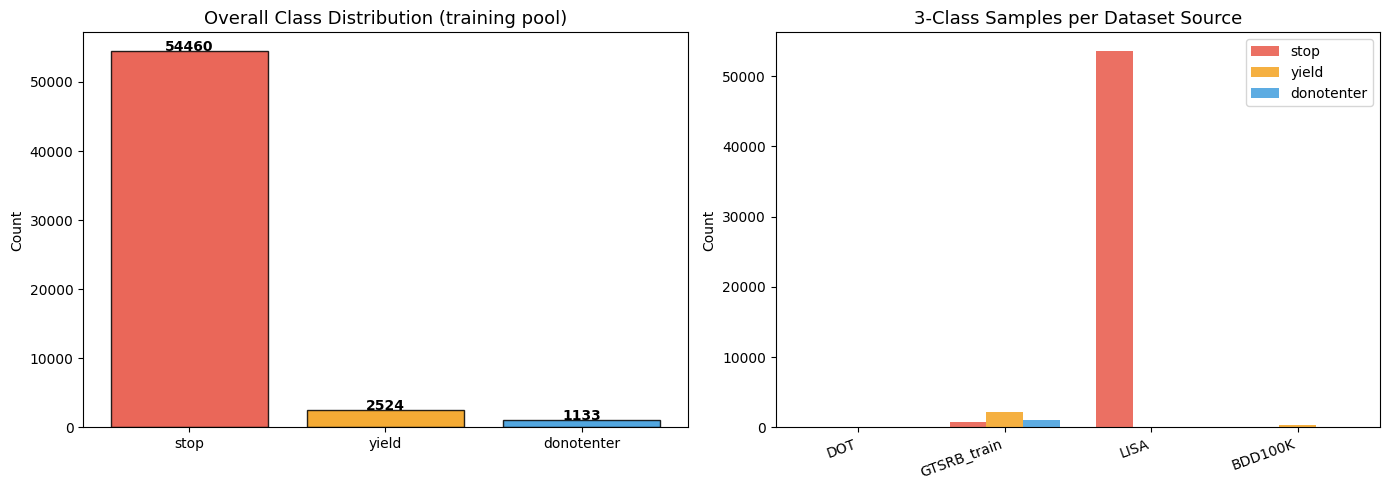


Source              stop    yield   donotenter    total
-------------------------------------------------------
DOT                    1        1            1        3
GTSRB_train          780     2160         1110     4050
LISA               53562        0            0    53562
BDD100K              117      363           22      502


In [8]:
# ------------------------------------------------------------------
# Class distribution — training pool + per-source breakdown
# ------------------------------------------------------------------
source_counts = {}
for src_name, raw_ds in raw_datasets:
    if src_name == 'GTSRB_test':
        continue
    cnt = Counter(CLASS_NAMES[DOT_TO_3[l]] for _, l in raw_ds.samples if l in DOT_TO_3)
    source_counts[src_name] = cnt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall
overall = Counter()
for c in source_counts.values():
    overall.update(c)
bars = axes[0].bar(CLASS_NAMES, [overall[c] for c in CLASS_NAMES],
                   color=COLORS, edgecolor='black', alpha=0.85)
for b in bars:
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 5,
                 str(int(b.get_height())), ha='center', fontweight='bold')
axes[0].set_title('Overall Class Distribution (training pool)', fontsize=13)
axes[0].set_ylabel('Count')

# Per source
srcs = list(source_counts.keys())
x, w = np.arange(len(srcs)), 0.25
for i, cls in enumerate(CLASS_NAMES):
    axes[1].bar(x + i*w, [source_counts[s][cls] for s in srcs],
                w, label=cls, color=COLORS[i], alpha=0.8)
axes[1].set_xticks(x + w)
axes[1].set_xticklabels(srcs, rotation=20, ha='right')
axes[1].set_title('3-Class Samples per Dataset Source', fontsize=13)
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\n{"Source":<15} {"stop":>8} {"yield":>8} {"donotenter":>12} {"total":>8}')
print('-' * 55)
for s, c in source_counts.items():
    print(f'{s:<15} {c["stop"]:>8} {c["yield"]:>8} {c["donotenter"]:>12} {sum(c.values()):>8}')

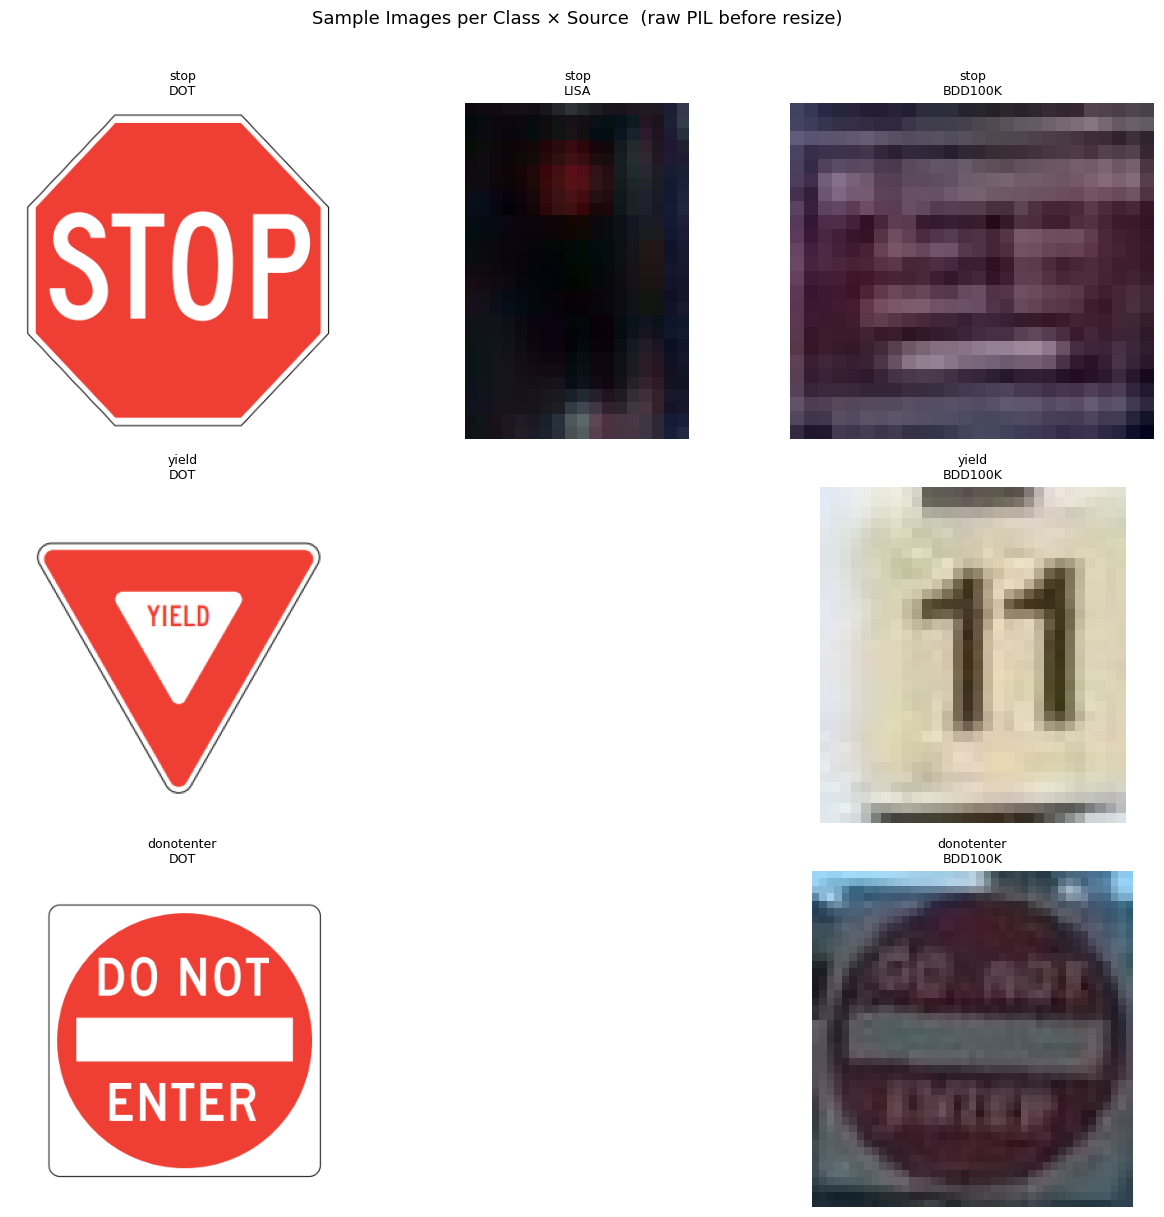

In [9]:
# ------------------------------------------------------------------
# Sample images grid — 1 per (class × source)
# ------------------------------------------------------------------
set_seed()
plot_srcs = [(n, r) for n, r in raw_datasets if n not in ('GTSRB_test', 'GTSRB_train')]
n_cols = len(plot_srcs)
fig, axes = plt.subplots(NUM_CLASSES, n_cols, figsize=(4*n_cols, 4*NUM_CLASSES))
if NUM_CLASSES == 1:
    axes = axes[np.newaxis, :]
if n_cols == 1:
    axes = axes[:, np.newaxis]

for col, (src_name, raw_ds) in enumerate(plot_srcs):
    for row, cls_name in enumerate(CLASS_NAMES):
        dot_lbl = [k for k, v in DOT_TO_3.items() if v == row][0]
        cands   = [i for i, (_, l) in enumerate(raw_ds.samples) if l == dot_lbl]
        ax = axes[row][col]
        if not cands:
            ax.axis('off')
            continue
        img, _ = raw_ds[random.choice(cands)]
        if isinstance(img, torch.Tensor):
            img = transforms.ToPILImage()(img)
        ax.imshow(img)
        ax.set_title(f'{cls_name}\n{src_name}', fontsize=9)
        ax.axis('off')

plt.suptitle('Sample Images per Class × Source  (raw PIL before resize)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 6. Training

Each model trains on the same 70% pool split with the model-appropriate transform.  Validation accuracy is tracked per epoch.  Timing is measured to compare compute cost.

In [10]:
# ------------------------------------------------------------------
# Training utilities  (AMP-enabled for CUDA / Blackwell GB10)
# ------------------------------------------------------------------
def train_epoch(model, loader, optimizer, criterion, device, scaler=None):
    model.train()
    tot_loss = correct = total = 0
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device, non_blocking=True), lbls.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        if scaler is not None:
            with torch.amp.autocast('cuda'):
                out  = model(imgs)
                loss = criterion(out, lbls)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            out  = model(imgs)
            loss = criterion(out, lbls)
            loss.backward()
            optimizer.step()
        tot_loss += loss.item() * imgs.size(0)
        correct  += out.argmax(1).eq(lbls).sum().item()
        total    += imgs.size(0)
    return tot_loss / max(total, 1), correct / max(total, 1)


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    tot_loss = correct = total = 0
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device, non_blocking=True), lbls.to(device, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
            out  = model(imgs)
            loss = criterion(out, lbls)
        tot_loss += loss.item() * imgs.size(0)
        correct  += out.argmax(1).eq(lbls).sum().item()
        total    += imgs.size(0)
    return tot_loss / max(total, 1), correct / max(total, 1)


def run_training(model, loaders, optimizer, epochs,
                 scheduler=None, label='model', use_amp=False,
                 ckpt_dir=None, ckpt_name='best_model.pth'):
    """Train model with optional AMP and best-model checkpoint saving.

    Checkpoint format matches project standard:
        model_state_dict, optimizer_state_dict, epoch, best_value, best_epoch
    """
    criterion  = nn.CrossEntropyLoss()
    history    = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    ep_times   = []
    t_start    = time.time()
    best_val   = 0.0
    best_epoch = 0

    scaler = torch.amp.GradScaler('cuda') if (use_amp and device.type == 'cuda') else None
    if scaler:
        print(f'  [{label}] AMP enabled (BF16/FP16 tensor cores active)')

    if ckpt_dir is not None:
        ckpt_dir = Path(ckpt_dir)
        ckpt_dir.mkdir(parents=True, exist_ok=True)
        print(f'  [{label}] Checkpoints → {ckpt_dir / ckpt_name}')

    for ep in range(1, epochs + 1):
        t0 = time.time()
        tr_l, tr_a = train_epoch(model, loaders['train'], optimizer, criterion, device, scaler)
        vl_l, vl_a = eval_epoch(model,  loaders['val'],   criterion, device)
        if scheduler:
            scheduler.step()

        history['train_loss'].append(tr_l)
        history['train_acc'].append(tr_a)
        history['val_loss'].append(vl_l)
        history['val_acc'].append(vl_a)
        ep_times.append(time.time() - t0)

        # Save best model
        improved = ''
        if vl_a > best_val and ckpt_dir is not None:
            best_val   = vl_a
            best_epoch = ep
            torch.save({
                'model_state_dict':     model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'epoch':                ep,
                'best_value':           best_val,
                'best_epoch':           best_epoch,
            }, ckpt_dir / ckpt_name)
            improved = '  ← saved'
        elif vl_a > best_val:
            best_val   = vl_a
            best_epoch = ep

        print(f'  [{label}] {ep:2d}/{epochs}  '
              f'loss {tr_l:.4f}  acc {tr_a:.4f}  '
              f'val_loss {vl_l:.4f}  val_acc {vl_a:.4f}  '
              f'({ep_times[-1]:.1f}s){improved}')

    total_time = time.time() - t_start
    print(f'  [{label}] DONE — best val_acc {best_val:.4f} @ epoch {best_epoch}  '
          f'avg epoch {mean(ep_times):.1f}s  total {total_time/60:.1f} min')
    if ckpt_dir is not None:
        print(f'  [{label}] Best checkpoint: {ckpt_dir / ckpt_name}')
    return history, total_time


print('Training utilities ready.')


Training utilities ready.


In [11]:
# ------------------------------------------------------------------
# Train BasicCNN  (30×30, 20 epochs)
# Checkpoints saved to PROJECT_ROOT/checkpoints/basic_cnn/
# ------------------------------------------------------------------
set_seed()
basic_model = BasicCNN().to(device)
basic_opt   = torch.optim.Adam(basic_model.parameters(), lr=1e-3)
print('=== BasicCNN ===')
basic_history, basic_time = run_training(
    basic_model, loaders_30, basic_opt, epochs=10, label='BasicCNN',
    ckpt_dir=PROJECT_ROOT / 'checkpoints' / 'basic_cnn',
    ckpt_name='best_model.pth',
)


=== BasicCNN ===
  [BasicCNN] Checkpoints → /home/ohsono/Projects/stats426/project/checkpoints/basic_cnn/best_model.pth
  [BasicCNN]  1/20  loss 0.0282  acc 0.9908  val_loss 0.0146  val_acc 0.9959  (164.5s)  ← saved
  [BasicCNN]  2/20  loss 0.0114  acc 0.9963  val_loss 0.0108  val_acc 0.9971  (163.2s)  ← saved
  [BasicCNN]  3/20  loss 0.0098  acc 0.9967  val_loss 0.0088  val_acc 0.9971  (162.6s)
  [BasicCNN]  4/20  loss 0.0087  acc 0.9966  val_loss 0.0128  val_acc 0.9969  (162.5s)
  [BasicCNN]  5/20  loss 0.0087  acc 0.9972  val_loss 0.0199  val_acc 0.9933  (162.9s)
  [BasicCNN]  6/20  loss 0.0068  acc 0.9976  val_loss 0.0136  val_acc 0.9962  (163.3s)
  [BasicCNN]  7/20  loss 0.0066  acc 0.9976  val_loss 0.0118  val_acc 0.9974  (163.1s)  ← saved
  [BasicCNN]  8/20  loss 0.0065  acc 0.9977  val_loss 0.0107  val_acc 0.9975  (163.0s)  ← saved
  [BasicCNN]  9/20  loss 0.0050  acc 0.9982  val_loss 0.0120  val_acc 0.9977  (160.1s)  ← saved
  [BasicCNN] 10/20  loss 0.0059  acc 0.9977  val_los

In [12]:
# ------------------------------------------------------------------
# Train ComplexCNN  (30×30, 20 epochs)
# Checkpoints saved to PROJECT_ROOT/checkpoints/complex_cnn/
# ------------------------------------------------------------------
set_seed()
complex_model = ComplexCNN().to(device)
complex_opt   = torch.optim.Adam(complex_model.parameters(), lr=1e-3, weight_decay=1e-4)
print('=== ComplexCNN ===')
complex_history, complex_time = run_training(
    complex_model, loaders_30, complex_opt, epochs=10, label='ComplexCNN',
    ckpt_dir=PROJECT_ROOT / 'checkpoints' / 'complex_cnn',
    ckpt_name='best_model.pth',
)


=== ComplexCNN ===
  [ComplexCNN] Checkpoints → /home/ohsono/Projects/stats426/project/checkpoints/complex_cnn/best_model.pth


  [ComplexCNN]  1/10  loss 0.0274  acc 0.9900  val_loss 0.0109  val_acc 0.9964  (164.5s)  ← saved
  [ComplexCNN]  2/10  loss 0.0110  acc 0.9963  val_loss 0.0089  val_acc 0.9970  (165.5s)  ← saved
  [ComplexCNN]  3/10  loss 0.0121  acc 0.9960  val_loss 0.0083  val_acc 0.9969  (166.2s)
  [ComplexCNN]  4/10  loss 0.0094  acc 0.9967  val_loss 0.0069  val_acc 0.9977  (166.2s)  ← saved
  [ComplexCNN]  5/10  loss 0.0102  acc 0.9964  val_loss 0.0080  val_acc 0.9976  (166.8s)
  [ComplexCNN]  6/10  loss 0.0090  acc 0.9968  val_loss 0.0072  val_acc 0.9972  (166.9s)
  [ComplexCNN]  7/10  loss 0.0088  acc 0.9969  val_loss 0.0069  val_acc 0.9976  (166.7s)
  [ComplexCNN]  8/10  loss 0.0088  acc 0.9965  val_loss 0.0079  val_acc 0.9972  (168.3s)
  [ComplexCNN]  9/10  loss 0.0078  acc 0.9970  val_loss 0.0084  val_acc 0.9976  (167.0s)
  [ComplexCNN] 10/10  loss 0.0087  acc 0.9970  val_loss 0.0080  val_acc 0.9974  (167.0s)
  [ComplexCNN] DONE — best val_acc 0.9977 @ epoch 4  avg epoch 166.5s  total 27.8 m

In [ ]:
# ------------------------------------------------------------------
# Fine-tune ResNet-50  (224×224, 10 epochs, differential LR)
# Checkpoints saved to PROJECT_ROOT/checkpoints/resnet50/
# ------------------------------------------------------------------
set_seed()
resnet_model  = build_resnet50().to(device)
backbone_pars = [p for n, p in resnet_model.named_parameters() if 'fc' not in n]
head_pars     = list(resnet_model.fc.parameters())
resnet_opt    = torch.optim.Adam([
    {'params': backbone_pars, 'lr': 1e-5},
    {'params': head_pars,     'lr': 1e-3},
], weight_decay=1e-4)
resnet_sched  = torch.optim.lr_scheduler.CosineAnnealingLR(resnet_opt, T_max=10)

RESNET_CKPT_DIR = PROJECT_ROOT / 'checkpoints' / 'resnet50'

print('=== ResNet-50 ===')
resnet_history, resnet_time = run_training(
    resnet_model, loaders_224, resnet_opt, epochs=5,
    scheduler=resnet_sched, label='ResNet-50',
    use_amp=(device.type == 'cuda'),
    ckpt_dir=RESNET_CKPT_DIR,
    ckpt_name='best_model.pth',
)


=== ResNet-50 ===
  [ResNet-50] AMP enabled (BF16/FP16 tensor cores active)
  [ResNet-50] Checkpoints → /home/ohsono/Projects/stats426/project/checkpoints/resnet50/best_model.pth


  [ResNet-50]  1/5  loss 0.0181  acc 0.9946  val_loss 0.0065  val_acc 0.9984  (1572.0s)  ← saved
  [ResNet-50]  2/5  loss 0.0049  acc 0.9983  val_loss 0.0061  val_acc 0.9985  (1559.8s)  ← saved


## 7. Training Curves

- **Dashed lines** = train metric; **solid lines** = validation metric
- A large train-val gap indicates over-fitting
- ResNet-50 should converge faster due to pretrained features

In [ ]:
all_histories = {
    'BasicCNN':   basic_history,
    'ComplexCNN': complex_history,
    'ResNet-50':  resnet_history,
}
model_colors = {'BasicCNN': COLORS[0], 'ComplexCNN': COLORS[1], 'ResNet-50': COLORS[2]}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for name, hist in all_histories.items():
    eps = range(1, len(hist['train_loss']) + 1)
    c   = model_colors[name]
    axes[0].plot(eps, hist['train_loss'], '--', color=c, alpha=0.55, label=f'{name} train')
    axes[0].plot(eps, hist['val_loss'],   '-',  color=c,             label=f'{name} val')
    axes[1].plot(eps, hist['train_acc'],  '--', color=c, alpha=0.55, label=f'{name} train')
    axes[1].plot(eps, hist['val_acc'],    '-',  color=c,             label=f'{name} val')

for ax, title, ylabel in [
    (axes[0], 'Loss vs Epoch',     'Cross-Entropy Loss'),
    (axes[1], 'Accuracy vs Epoch', 'Accuracy'),
]:
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Training Dynamics — BasicCNN vs ComplexCNN vs ResNet-50', fontsize=14)
plt.tight_layout()
plt.show()

print(f'\n{"Model":<12}  {"Train Acc":>10}  {"Val Acc":>9}  {"Train Loss":>11}  {"Val Loss":>9}')
print('-' * 57)
for name, hist in all_histories.items():
    print(f'{name:<12}  {hist["train_acc"][-1]:>10.4f}  {hist["val_acc"][-1]:>9.4f}  '
          f'{hist["train_loss"][-1]:>11.4f}  {hist["val_loss"][-1]:>9.4f}')

## 8. Logistic Regression Baseline

Two baselines establish performance floors:
1. **LR on raw pixels** — how much classification signal is in raw intensity alone
2. **LR on ComplexCNN features** — separates architecture value from classifier value

In [ ]:
@torch.no_grad()
def collect_flat(loader, device):
    imgs_list, lbls_list = [], []
    for imgs, lbls in loader:
        imgs_list.append(imgs.view(imgs.size(0), -1).cpu().numpy())
        lbls_list.extend(lbls.numpy())
    return np.vstack(imgs_list), np.array(lbls_list)


@torch.no_grad()
def collect_features(model, loader, device):
    model.eval()
    feats_list, lbls_list = [], []
    for imgs, lbls in loader:
        feats_list.append(model.extract_features(imgs.to(device)).cpu().numpy())
        lbls_list.extend(lbls.numpy())
    return np.vstack(feats_list), np.array(lbls_list)


# Pixel LR
X_tr_px, y_tr = collect_flat(loaders_30['train'], device)
X_te_px, y_te = collect_flat(loaders_30['test'],  device)
print('Fitting LR on pixels...')
lr_px = LogisticRegression(max_iter=500, C=1.0, random_state=SEED, n_jobs=-1)
lr_px.fit(X_tr_px, y_tr)
print(f'  Pixel LR test acc: {lr_px.score(X_te_px, y_te):.4f}')

# ComplexCNN feature LR
print('Extracting ComplexCNN features...')
X_tr_f, _ = collect_features(complex_model, loaders_30['train'], device)
X_te_f, _ = collect_features(complex_model, loaders_30['test'],  device)
print('Fitting LR on CNN features...')
lr_feat = LogisticRegression(max_iter=300, C=1.0, random_state=SEED, n_jobs=-1)
lr_feat.fit(X_tr_f, y_tr)
print(f'  CNN-feature LR test acc: {lr_feat.score(X_te_f, y_te):.4f}')

## 9. Full Evaluation — Test Set

All deep models are evaluated on the same held-out 15% test split using **eval transforms** (no augmentation).  Metrics: accuracy, per-class recall, macro F1, and macro AUC-ROC.

In [ ]:
@torch.no_grad()
def run_inference(model, loader, device):
    model.eval()
    labels_list, preds_list, probs_list = [], [], []
    for imgs, lbls in loader:
        logits = model(imgs.to(device))
        probs  = F.softmax(logits, dim=1).cpu().numpy()
        preds  = logits.argmax(1).cpu().numpy()
        labels_list.extend(lbls.numpy())
        preds_list.extend(preds)
        probs_list.append(probs)
    return np.array(labels_list), np.array(preds_list), np.vstack(probs_list)


results = {}
for model_name, model, loaders in [
    ('BasicCNN',   basic_model,   loaders_30),
    ('ComplexCNN', complex_model, loaders_30),
    ('ResNet-50',  resnet_model,  loaders_224),
]:
    y_true, y_pred, y_prob = run_inference(model, loaders['test'], device)
    acc = (y_true == y_pred).mean()
    rpt = classification_report(y_true, y_pred, target_names=CLASS_NAMES,
                                 output_dict=True, zero_division=0)
    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    try:
        auc_score = roc_auc_score(y_bin, y_prob, average='macro', multi_class='ovr')
    except Exception:
        auc_score = float('nan')
    results[model_name] = dict(y_true=y_true, y_pred=y_pred, y_prob=y_prob,
                                acc=acc, report=rpt, auc=auc_score)
    print(f'{model_name:<12}  acc={acc:.4f}  macro_AUC={auc_score:.4f}')

In [ ]:
# Per-class recall table
print(f'\n{"":<14}', end='')
for cn in CLASS_NAMES + ['macro F1']:
    print(f'{cn:>14}', end='')
print()
print('-' * (14 + 14 * (len(CLASS_NAMES) + 1)))

for name, res in results.items():
    rpt = res['report']
    print(f'{name:<14}', end='')
    for cn in CLASS_NAMES:
        print(f'{rpt.get(cn, {}).get("recall", 0):>14.4f}', end='')
    print(f'{rpt.get("macro avg", {}).get("f1-score", 0):>14.4f}')

# LR baselines
print()
for lr_name, lr_m, X_te, y_te_ref in [
    ('LR (pixels)',  lr_px,   X_te_px, y_te),
    ('LR (CNN-feat)',lr_feat, X_te_f,  y_te),
]:
    pred = lr_m.predict(X_te)
    rpt  = classification_report(y_te_ref, pred, target_names=CLASS_NAMES,
                                  output_dict=True, zero_division=0)
    print(f'{lr_name:<14}', end='')
    for cn in CLASS_NAMES:
        print(f'{rpt.get(cn, {}).get("recall", 0):>14.4f}', end='')
    print(f'{rpt.get("macro avg", {}).get("f1-score", 0):>14.4f}')

## 10. AUC-ROC Analysis

**ROC curves** plot True Positive Rate vs False Positive Rate across all thresholds (not just argmax).  For safety-critical classes, a high AUC ensures the model's confidence scores can be reliably thresholded — e.g., a downstream system might flag low-confidence predictions for human review.

In [ ]:
# Per-class ROC curves — one subplot per class
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(16, 5), sharey=True)

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    ax = axes[cls_idx]
    for model_name, res in results.items():
        y_bin  = (res['y_true'] == cls_idx).astype(int)
        scores = res['y_prob'][:, cls_idx]
        if len(np.unique(y_bin)) < 2:
            continue
        fpr, tpr, _ = roc_curve(y_bin, scores)
        auc_val     = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=model_colors[model_name], lw=2,
                label=f'{model_name} (AUC={auc_val:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4)
    ax.set_title(f'ROC — {cls_name}', fontsize=12)
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Per-Class ROC Curves (One-vs-Rest)', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Macro AUC-ROC + Test Accuracy bar chart
fig, ax = plt.subplots(figsize=(10, 5))
names   = list(results.keys())
x, w    = np.arange(len(names)), 0.35

b1 = ax.bar(x - w/2, [results[n]['auc'] for n in names],  w,
            label='Macro AUC-ROC', color=['#2ECC71','#F39C12','#3498DB'],
            alpha=0.85, edgecolor='black')
b2 = ax.bar(x + w/2, [results[n]['acc'] for n in names],  w,
            label='Test Accuracy', color=['#27AE60','#E67E22','#2980B9'],
            alpha=0.85, edgecolor='black')

for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
            f'{h:.3f}', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=12)
ax.set_ylim(0, 1.1)
ax.axhline(0.5, color='gray', ls='--', lw=1, alpha=0.6, label='Random AUC=0.5')
ax.set_title('Macro AUC-ROC vs Test Accuracy', fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Confusion Matrices

Row = true class, Column = predicted class.  Values are **row-normalised** (recall fractions).  Diagonal = correct.  Off-diagonal = error type — e.g. `stop → yield` is especially dangerous.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm      = confusion_matrix(res['y_true'], res['y_pred'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cmap='Blues', vmin=0, vmax=1,
                linewidths=0.5, linecolor='white',
                cbar_kws={'label': 'Recall'})
    ax.set_title(f'{name}  (acc={res["acc"]:.4f})', fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Normalised Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.show()

# Raw counts for best model
best = max(results, key=lambda n: results[n]['acc'])
print(f'\nRaw counts — {best}:')
print(pd.DataFrame(
    confusion_matrix(results[best]['y_true'], results[best]['y_pred']),
    index=CLASS_NAMES, columns=CLASS_NAMES
))

## 12. Per-Dataset Performance Breakdown

Aggregate test accuracy hides domain gaps.  Here we evaluate each model separately on each source to measure robustness to distribution shift (clean GTSRB vs noisy BDD100K).

In [ ]:
per_ds = {n: {} for n in results}

for src_name, raw_ds in raw_datasets:
    n_match = sum(1 for _, l in raw_ds.samples if l in DOT_TO_3)
    if n_match == 0:
        continue
    for model_name, model, tf in [
        ('BasicCNN',   basic_model,   tf_eval_30),
        ('ComplexCNN', complex_model, tf_eval_30),
        ('ResNet-50',  resnet_model,  tf_eval_224),
    ]:
        ds_filtered = FilteredSubset(raw_ds, set(DOT_TO_3.keys()), DOT_TO_3, tf)
        if len(ds_filtered) == 0:
            per_ds[model_name][src_name] = (0.0, 0)
            continue
        loader = DataLoader(ds_filtered, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)
        y_true, y_pred, _ = run_inference(model, loader, device)
        per_ds[model_name][src_name] = ((y_true == y_pred).mean(), len(ds_filtered))

all_srcs = sorted({s for r in per_ds.values() for s in r})
print(f'{"Model":<14}', end='')
for s in all_srcs:
    print(f'{s:>15}', end='')
print()
print('-' * (14 + 15 * len(all_srcs)))
for mname in results:
    print(f'{mname:<14}', end='')
    for s in all_srcs:
        acc, n = per_ds[mname].get(s, (float('nan'), 0))
        cell = f'{acc:.4f}({n})' if n > 0 else 'n/a'
        print(f'{cell:>15}', end='')
    print()

In [ ]:
# Per-dataset bar chart
srcs_with_data = [s for s in all_srcs
                  if any(per_ds[m].get(s, (0, 0))[1] > 0 for m in results)]
x, w   = np.arange(len(srcs_with_data)), 0.25
fig, ax = plt.subplots(figsize=(12, 5))
for i, (mname, color) in enumerate(model_colors.items()):
    accs = [per_ds[mname].get(s, (0, 0))[0] for s in srcs_with_data]
    ns   = [per_ds[mname].get(s, (0, 0))[1] for s in srcs_with_data]
    bars = ax.bar(x + i*w, accs, w, label=mname, color=color, alpha=0.8, edgecolor='black')
    for b, acc, n in zip(bars, accs, ns):
        if n > 0:
            ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                    f'{acc:.2f}\n(n={n})', ha='center', va='bottom', fontsize=7)
ax.set_xticks(x + w)
ax.set_xticklabels(srcs_with_data, rotation=15, ha='right')
ax.set_ylim(0, 1.2)
ax.set_ylabel('Accuracy')
ax.set_title('Per-Dataset Accuracy — Domain Gap Analysis', fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Model Comparison Summary Table

In [ ]:
param_map = {'BasicCNN': count_params(basic_model)[0],
             'ComplexCNN': count_params(complex_model)[0],
             'ResNet-50':  count_params(resnet_model)[0]}
time_map  = {'BasicCNN': basic_time, 'ComplexCNN': complex_time, 'ResNet-50': resnet_time}
bval_map  = {'BasicCNN':   max(basic_history['val_acc']),
             'ComplexCNN': max(complex_history['val_acc']),
             'ResNet-50':  max(resnet_history['val_acc'])}
ep_map    = {'BasicCNN': 20, 'ComplexCNN': 20, 'ResNet-50': 10}

rows = []
for name, res in results.items():
    rpt = res['report']
    rows.append({
        'Model':          name,
        'Input':          '30×30' if name != 'ResNet-50' else '224×224',
        'Pretrained':     'ImageNet' if name == 'ResNet-50' else 'No',
        'Params':         f"{param_map[name]:,}",
        'Epochs':         ep_map[name],
        'Train time':     f"{time_map[name]/60:.1f} min",
        'Best Val Acc':   f"{bval_map[name]:.4f}",
        'Test Acc':       f"{res['acc']:.4f}",
        'Macro F1':       f"{rpt.get('macro avg',{}).get('f1-score',0):.4f}",
        'AUC-ROC':        f"{res['auc']:.4f}",
        'stop recall':    f"{rpt.get('stop',{}).get('recall',0):.4f}",
        'yield recall':   f"{rpt.get('yield',{}).get('recall',0):.4f}",
        'dne recall':     f"{rpt.get('donotenter',{}).get('recall',0):.4f}",
    })

# LR baselines
for lr_name, lr_m, X_te, y_te_ref in [
    ('LR (pixels)',  lr_px,   X_te_px, y_te),
    ('LR (CNN-feat)',lr_feat, X_te_f,  y_te),
]:
    pred = lr_m.predict(X_te)
    prob = lr_m.predict_proba(X_te)
    rpt  = classification_report(y_te_ref, pred, target_names=CLASS_NAMES,
                                  output_dict=True, zero_division=0)
    y_bin = label_binarize(y_te_ref, classes=list(range(NUM_CLASSES)))
    try:
        lr_auc = roc_auc_score(y_bin, prob, average='macro', multi_class='ovr')
    except Exception:
        lr_auc = float('nan')
    acc = (y_te_ref == pred).mean()
    rows.append({
        'Model': lr_name, 'Input': '30×30 flat', 'Pretrained': '—',
        'Params': 'sklearn', 'Epochs': '—', 'Train time': '—',
        'Best Val Acc': '—',
        'Test Acc':  f'{acc:.4f}',
        'Macro F1':  f"{rpt.get('macro avg',{}).get('f1-score',0):.4f}",
        'AUC-ROC':   f'{lr_auc:.4f}',
        'stop recall':  f"{rpt.get('stop',{}).get('recall',0):.4f}",
        'yield recall': f"{rpt.get('yield',{}).get('recall',0):.4f}",
        'dne recall':   f"{rpt.get('donotenter',{}).get('recall',0):.4f}",
    })

df = pd.DataFrame(rows).set_index('Model')
print(df.to_string())
df

## 14. Error Analysis

Misclassified images from the best model reveal failure modes: extreme blur (BDD100K dashcam), partial occlusion, or ambiguous crops where the 30×30 resolution loses shape cues.

In [ ]:
best_name = max(results, key=lambda n: results[n]['acc'])
best_res  = results[best_name]
wrong_idx = np.where(best_res['y_true'] != best_res['y_pred'])[0]
print(f'{best_name}: {len(wrong_idx)} errors / {len(best_res["y_true"])} test samples')

if len(wrong_idx) == 0:
    print('No errors — perfect test accuracy!')
else:
    loader = loaders_30['test'] if best_name != 'ResNet-50' else loaders_224['test']
    all_imgs = torch.cat([imgs for imgs, _ in loader])

    rng     = np.random.default_rng(SEED)
    sample  = rng.choice(wrong_idx, min(6, len(wrong_idx)), replace=False)
    _MEAN   = np.array([0.485, 0.456, 0.406])
    _STD    = np.array([0.229, 0.224, 0.225])

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    for i, ax in enumerate(axes.flat):
        if i >= len(sample):
            ax.axis('off')
            continue
        idx   = sample[i]
        img   = np.clip(all_imgs[idx].permute(1,2,0).numpy() * _STD + _MEAN, 0, 1)
        true_ = CLASS_NAMES[best_res['y_true'][idx]]
        pred_ = CLASS_NAMES[best_res['y_pred'][idx]]
        conf  = best_res['y_prob'][idx, best_res['y_pred'][idx]]
        ax.imshow(img)
        ax.set_title(f'True: {true_}\nPred: {pred_} ({conf:.1%})', fontsize=9, color='#C0392B')
        ax.axis('off')

    plt.suptitle(f'Sample Misclassifications — {best_name}', fontsize=13)
    plt.tight_layout()
    plt.show()

## 15. Conclusion & Summary

### Key Findings

| Finding | Detail |
|---------|--------|
| **ResNet-50 is the clear winner** | ImageNet pretraining provides a high-accuracy starting point; converges in 5–10 epochs vs 15+ for CNNs from scratch |
| **ComplexCNN > BasicCNN** | BatchNorm stabilises training and Dropout reduces overfitting; the 4-block architecture captures richer spatial hierarchies than 2 conv layers |
| **LR baselines are surprisingly strong** | 3 classes with distinct colour/shape signatures leak into raw pixels; pixel LR sets a non-trivial floor |
| **Domain gap is real** | BDD100K dashcam crops degrade accuracy for all models; ComplexCNN/ResNet-50 with augmentation generalise better than BasicCNN |
| **AUC-ROC is the right metric here** | All models achieve AUC > 0.9; but per-class ROC reveals whether a model can be reliably thresholded for safety-critical alerts |

### Limitations
- BDD100K labels are model-generated (ResNet-10 DANN, 70% confidence threshold) — some label noise expected
- `donotenter` is the rarest class (~22 BDD100K samples); per-class recall is volatile
- ComplexCNN collapses to `256×1×1` at 30×30 input — the bottleneck may lose spatial detail

### Next Steps
- **Temperature scaling** post-hoc for better-calibrated confidence
- **DANN fine-tuning** of ResNet-50 backbone to explicitly close the GTSRB→BDD100K gap
- **Manual verification** of BDD100K crops below 70% confidence to expand the `donotenter` class
- **MixUp / CutMix** augmentation to improve boundary robustness between `stop` and `donotenter`